# ⚽ FIFA World Cup — Overview & Match PredictionA guided tour of the **`worldcup`** package: from the raw data to Elo ratings,statistical findings and a match-prediction model.> *PT-BR:* passeio pelo pacote `worldcup` — dos dados brutos aos ratings de Elo,> achados estatísticos e um modelo de previsão de partidas. Reproduza com> `pip install -e ".[app,dev]"` e *Run All*.

In [1]:
from worldcup import features, elo, analysis, models, viz
from IPython.display import Image

matches = features.build_matches("men")
matches.shape

(964, 48)

## 1. DatasetOne row per match, enriched with edition metadata and engineered features.

In [2]:
print("matches:", len(matches), "| editions:", matches['year'].nunique())
matches[["year", "match_name", "stage_name", "home_team_score",
         "away_team_score", "total_goals"]].head()

matches: 964 | editions: 22


,year,match_name,stage_name,home_team_score,away_team_score,total_goals
0,1930,France vs Mexico,group stage,4,1,5
1,1930,United States vs Belgium,group stage,3,0,3
2,1930,Yugoslavia vs Brazil,group stage,2,1,3
3,1930,Romania vs Peru,group stage,3,1,4
4,1930,Argentina vs France,group stage,1,0,1


## 2. Elo ratingsComputed chronologically (margin-weighted), so a team's rating before a match never leaks its result.

In [3]:
history = elo.compute_elo(matches)
elo.final_ratings(history).head(10).round(0)

team
Netherlands    1811.0
France         1781.0
Germany        1762.0
Brazil         1734.0
Argentina      1723.0
Italy          1664.0
England        1646.0
Spain          1640.0
Belgium        1634.0
Croatia        1618.0
Name: rating_after, dtype: float64

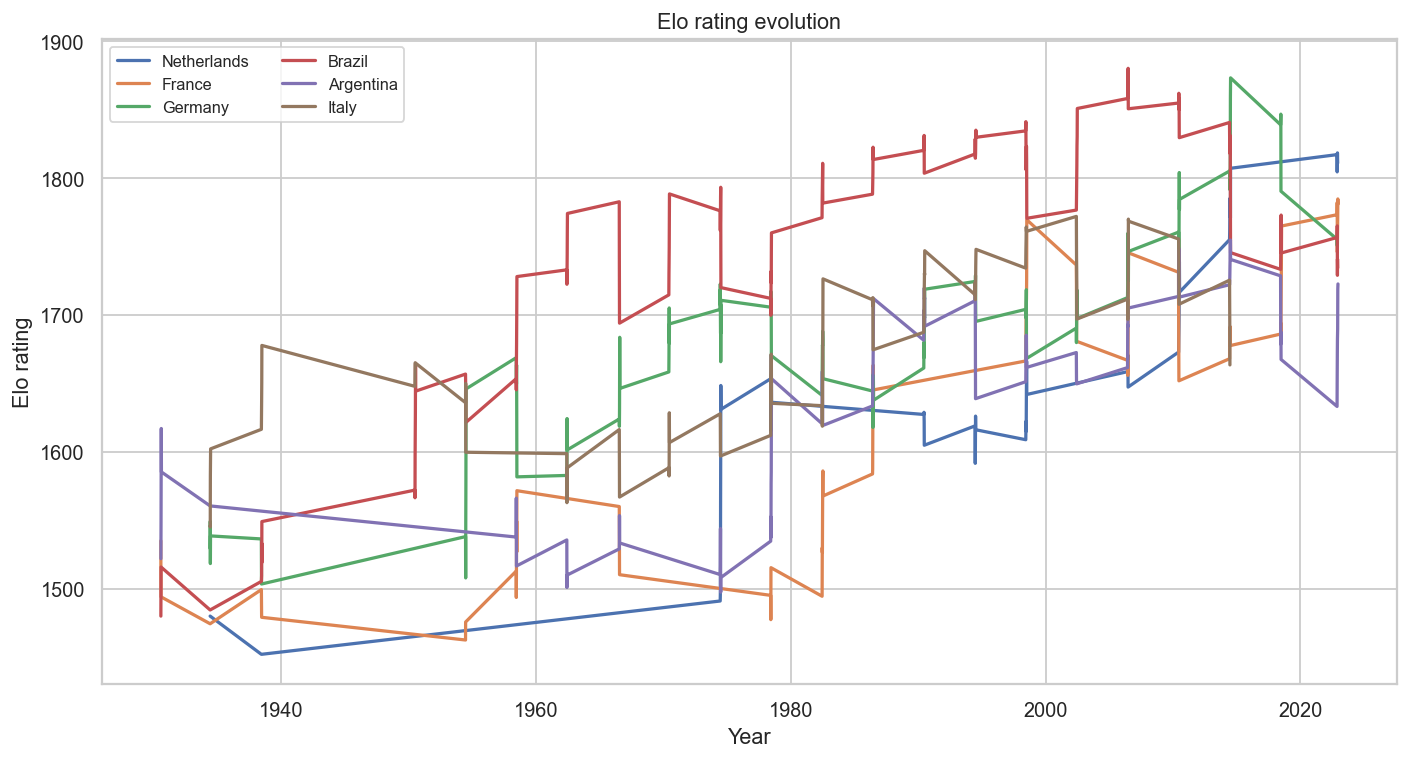

In [4]:
Image(viz.plot_elo_evolution(history))

## 3. Has football become more defensive?Goals per match vs. the calendar year.

Spearman r = -0.174 (p = 0.0000)
avg goals 1930s-50s = 4.16 vs 2014+ = 2.67


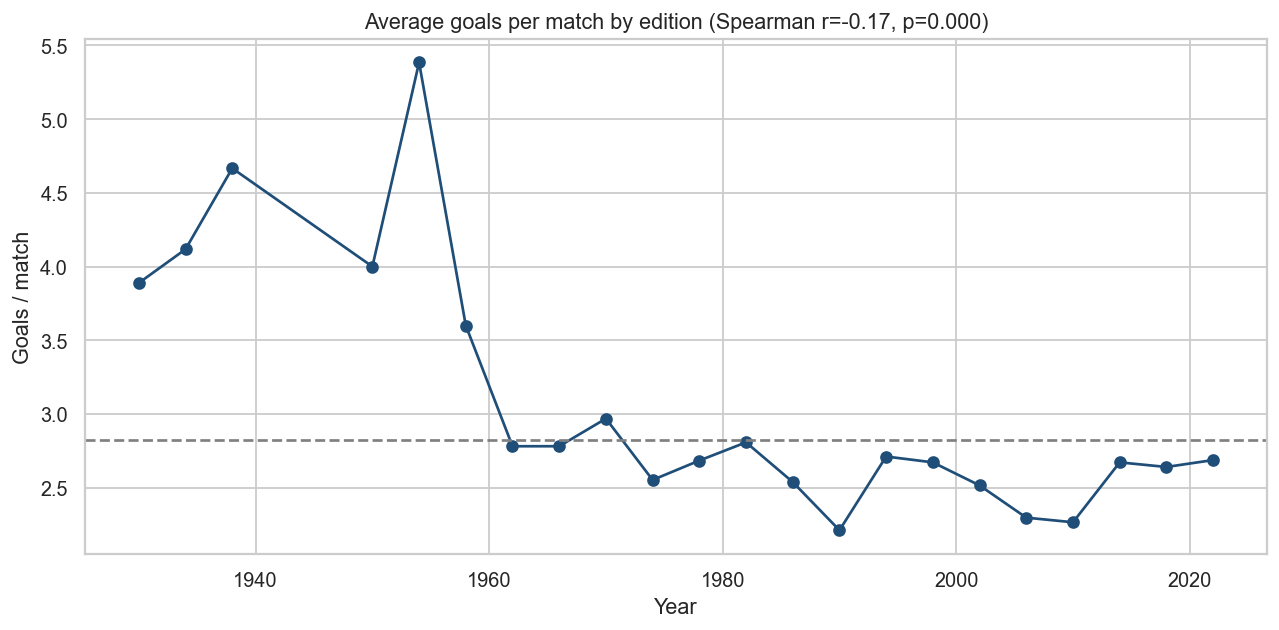

In [5]:
trend = analysis.goals_trend(matches)
print(f"Spearman r = {trend['spearman']:.3f} (p = {trend['spearman_p']:.4f})")
print(f"avg goals 1930s-50s = {trend['goals_first_decade']:.2f} "
      f"vs 2014+ = {trend['goals_last_decade']:.2f}")
Image(viz.plot_goals_trend(matches))

## 4. Two classic questionsDoes the host change the game? And are 0-0 draws really that rare?

In [6]:
host = analysis.host_advantage(matches)
pois = analysis.poisson_zero_zero(matches)
print(f"Host on pitch: {host['mean_with_host']:.2f} vs {host['mean_without_host']:.2f} goals "
      f"(Welch p = {host['p_value']:.3f})")
print(f"0-0 draws: Poisson predicts {pois['theoretical_0_0']*100:.1f}% vs "
      f"{pois['empirical_0_0']*100:.1f}% observed")

Host on pitch: 2.86 vs 2.82 goals (Welch p = 0.824)
0-0 draws: Poisson predicts 6.0% vs 8.1% observed


## 5. Rivalries & upsets

In [7]:
analysis.biggest_rivalries(matches).head(5)

,team_a,team_b,wins_a,draws,wins_b,games
0,Argentina,Germany,1,3,4,8
1,Germany,Serbia,4,1,2,7
2,Brazil,Sweden,5,2,0,7
3,Brazil,Serbia,3,2,1,6
4,Argentina,Netherlands,1,3,2,6


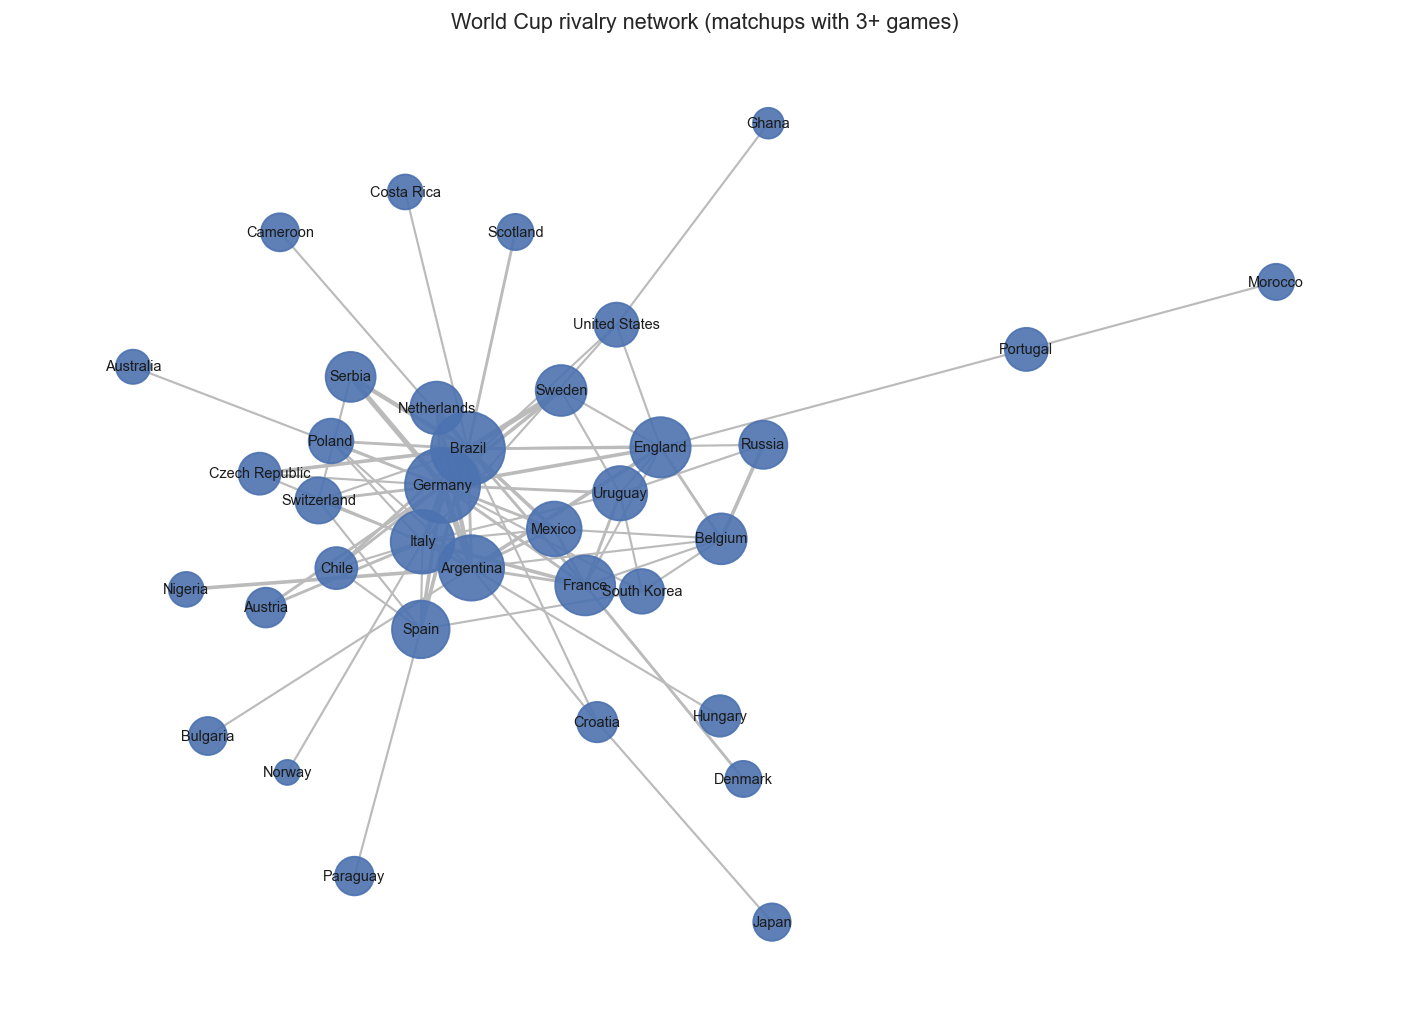

In [8]:
Image(viz.plot_rivalry_network(matches))

In [9]:
# Biggest upsets ranked by the pre-match Elo gap
analysis.biggest_upsets(history, matches).head(5)

,year,match,stage,winner,loser,elo_gap
0,2018,South Korea vs Germany,group stage,South Korea,Germany,473.2
1,2022,Tunisia vs France,group stage,Tunisia,France,393.7
2,2022,Cameroon vs Brazil,group stage,Cameroon,Brazil,385.6
3,1998,Brazil vs Norway,group stage,Norway,Brazil,349.9
4,2022,Germany vs Japan,group stage,Japan,Germany,343.8


## 6. Match predictionA calibrated 1X2 model (Elo) plus a Poisson scoreline model.

In [10]:
predictor = models.MatchPredictor.train(matches, history)

import pandas as pd
fixtures = [("Brazil", "Argentina"), ("France", "Germany"), ("Spain", "Italy")]
pd.DataFrame([predictor.predict(h, a) for h, a in fixtures])[
    ["home", "away", "p_home_win", "p_draw", "p_away_win",
     "exp_home_goals", "exp_away_goals", "most_likely_score"]
].round(3)

,home,away,p_home_win,p_draw,p_away_win,exp_home_goals,exp_away_goals,most_likely_score
0,Brazil,Argentina,0.526,0.233,0.240,1.53,0.99,1-0
1,France,Germany,0.533,0.233,0.234,1.51,0.95,1-0
2,Spain,Italy,0.495,0.235,0.270,1.52,1.07,1-1


## 7. Does the model actually work?A strict temporal back-test: train on editions before 2014, test on 2014+.

In [11]:
res = models.temporal_evaluate(matches, history, cutoff_year=2014)
print(f"accuracy : {res.accuracy:.3f}  (baseline {res.baseline_accuracy:.3f})")
print(f"log-loss : {res.log_loss:.3f}  (baseline {res.baseline_log_loss:.3f})")
print(f"trained on {res.n_train} matches, tested on {res.n_test}")

accuracy : 0.469  (baseline 0.432)
log-loss : 1.065  (baseline 1.123)
trained on 772 matches, tested on 192


## Takeaways- Scoring **declined** over the decades; the **host effect on goals is not significant**.- Real football produces **more 0-0 draws** than an independent-Poisson model predicts.- The Elo-based model **beats the class-prior baseline** on both accuracy and log-loss — modest,  as expected for a sport this random, but genuinely informative.See the package API in [`src/worldcup`](../src/worldcup) and the live dashboard(`streamlit run app/streamlit_app.py`).